In [1]:
import pandas as pd
df = pd.read_csv("2008_all_states.csv")
df

,state,county,total_votes,dem_votes,rep_votes,other_votes,dem_share,east_west
0,AK,"State House District 8, Denali-University",10320,4995,4983,342,50.06,west
1,AK,"State House District 37, Bristol Bay-Aleuti",4665,1868,2661,136,41.24,west
2,AK,"State House District 12, Richardson-Glenn H",7589,1914,5467,208,25.93,west
3,AK,"State House District 13, Greater Palmer",11526,2800,8432,294,24.93,west
4,AK,"State House District 14, Greater Wasilla",10456,2132,8108,216,20.82,west
...,...,...,...,...,...,...,...,...
3148,OH,Hamilton County,425086,225213,195530,4343,53.53,east
3149,OH,Highland County,19186,6856,11907,423,36.54,east
3150,OH,Hocking County,12961,6259,6364,338,49.58,east
3151,OH,Licking County,82356,33932,46918,1506,41.97,east


In [2]:
df.shape

(3153, 8)

# Descriptive statistics

In [3]:
df.describe()

,total_votes,dem_votes,rep_votes,other_votes,dem_share
count,3.153000e+03,3.153000e+03,3153.000000,3153.000000,3153.000000
mean,4.171013e+04,2.206070e+04,19019.719632,582.779258,42.214653
std,1.192757e+05,7.668304e+04,44604.561162,1834.898291,14.046978
min,7.900000e+01,8.000000e+00,67.000000,0.000000,5.030000
25%,5.015000e+03,1.832000e+03,2889.000000,71.000000,31.980000
50%,1.086800e+04,4.434000e+03,6270.000000,171.000000,41.770000
75%,2.856200e+04,1.209400e+04,15775.000000,434.000000,51.280000
max,3.318248e+06,2.295853e+06,956425.000000,65970.000000,93.430000


In [4]:
# Mean
print("MEAN")
print(df.mean(numeric_only=True))

# Median
print("\nMEDIAN")
print(df.median(numeric_only=True))

# Standard deviation
print("\nSTANDARD DEVIATION")
print(df.std(numeric_only=True))

# Quartiles
print("\nQUARTILES")
print(df.quantile([0.25, 0.50, 0.75], numeric_only=True))

MEAN
total_votes    41710.125595
dem_votes      22060.702188
rep_votes      19019.719632
other_votes      582.779258
dem_share         42.214653
dtype: float64

MEDIAN
total_votes    10868.00
dem_votes       4434.00
rep_votes       6270.00
other_votes      171.00
dem_share         41.77
dtype: float64

STANDARD DEVIATION
total_votes    119275.713054
dem_votes       76683.041652
rep_votes       44604.561162
other_votes      1834.898291
dem_share          14.046978
dtype: float64

QUARTILES
      total_votes  dem_votes  rep_votes  other_votes  dem_share
0.25       5015.0     1832.0     2889.0         71.0      31.98
0.50      10868.0     4434.0     6270.0        171.0      41.77
0.75      28562.0    12094.0    15775.0        434.0      51.28


# Correlation heatmap 

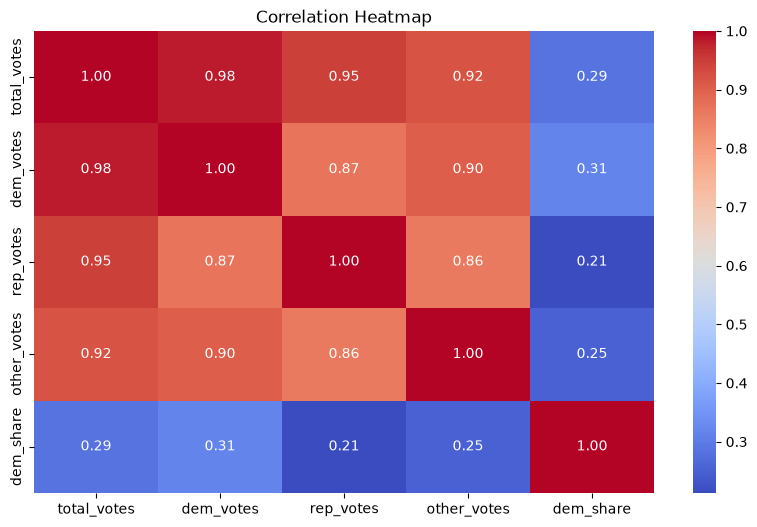

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Histograms

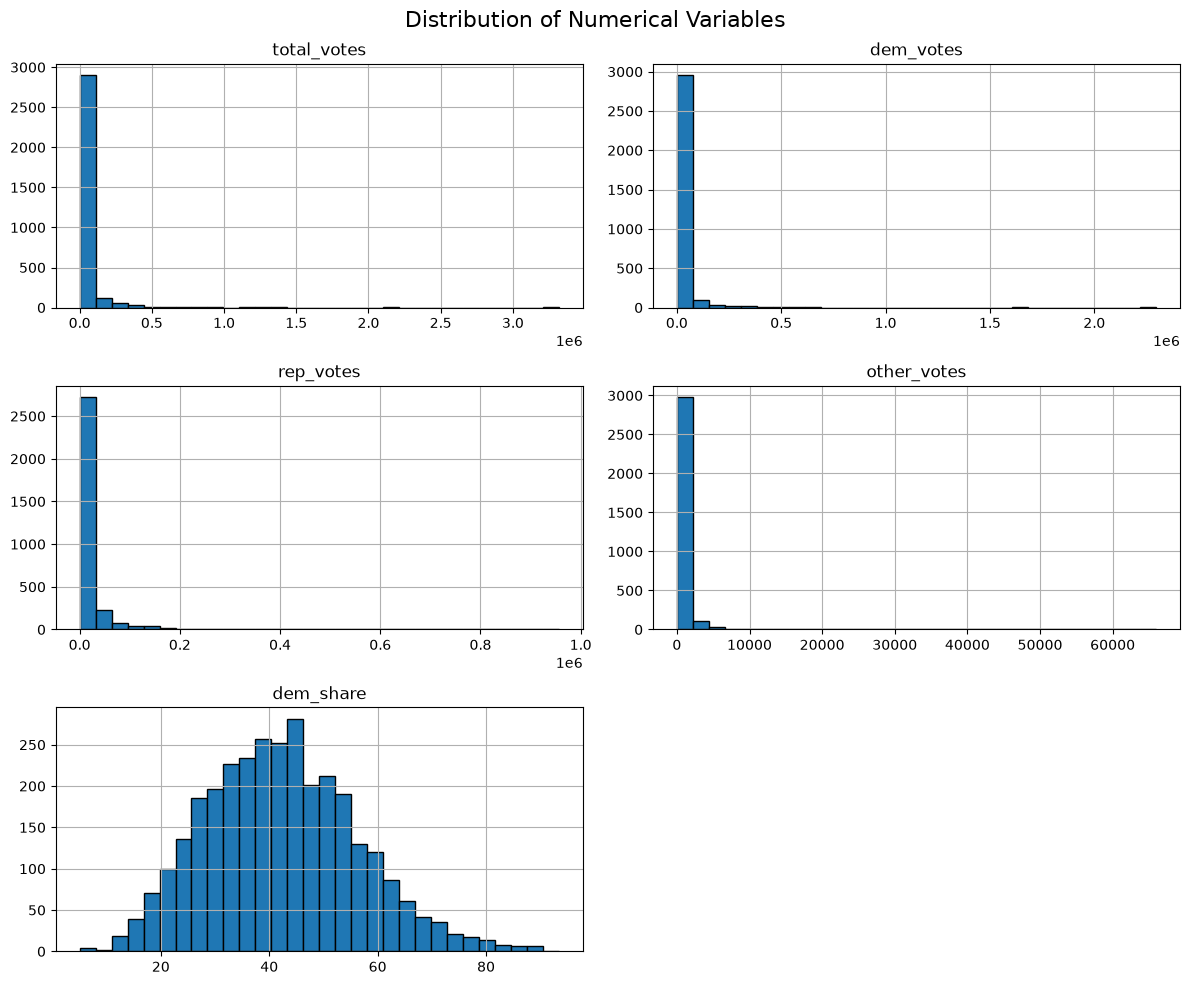

In [7]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols].hist(
    figsize=(12, 10),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

# Box Plots

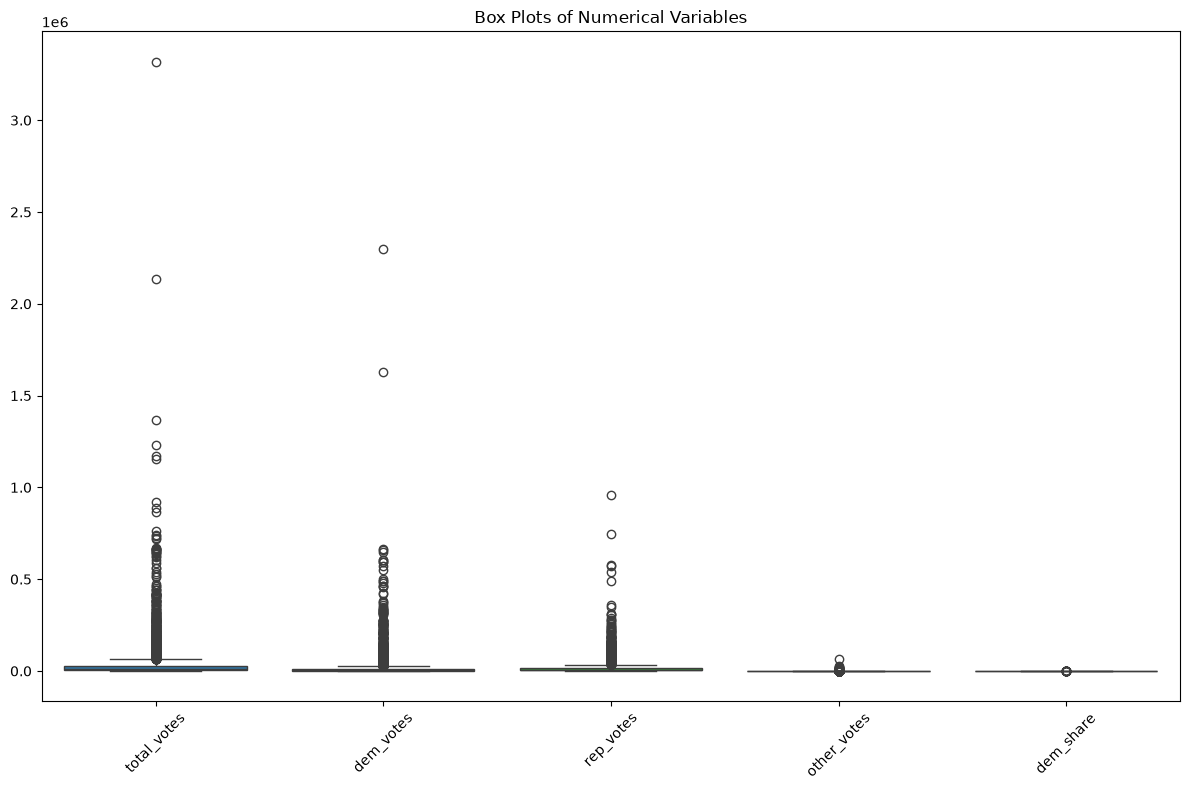

In [8]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.title("Box Plots of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hypotheses- 1: Higher total_votes is associated with higher dem_votes.

In [9]:
from scipy.stats import pearsonr

r, p = pearsonr(df["total_votes"], df["dem_votes"])

print("H1: Total votes vs Democratic votes")
print("Correlation:", round(r, 4))
print("p-value:", p)

H1: Total votes vs Democratic votes
Correlation: 0.9821
p-value: 0.0


# Hypotheses- 2: dem_votes and rep_votes are positively correlated across districts.

In [11]:
r, p = pearsonr(df["dem_votes"], df["rep_votes"])

print("H2: Democratic votes vs Republican votes")
print("Correlation:", round(r, 4))
print("p-value:", p)

H2: Democratic votes vs Republican votes
Correlation: 0.8697
p-value: 0.0


# Hypotheses -3: Democratic vote share (dem_share) differs between the East and West groups.

In [12]:
print(df["east_west"].value_counts())

east_west
east    1607
west    1546
Name: count, dtype: int64


In [13]:
from scipy.stats import ttest_ind

east_share = df.loc[df["east_west"] == "east", "dem_share"]
west_share = df.loc[df["east_west"] == "west", "dem_share"]

t_stat, p_value = ttest_ind(east_share, west_share, equal_var=False)

print("H3: Democratic vote share — East vs West")
print("East mean:", round(east_share.mean(), 2))
print("West mean:", round(west_share.mean(), 2))
print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

H3: Democratic vote share — East vs West
East mean: 45.42
West mean: 38.89
t-statistic: 13.3891
p-value: 8.83784266273316e-40


## 5 Critical Findings

1. **Strong relationship between total votes and Democratic votes:** Total votes and Democratic votes show a very strong positive correlation (r = 0.9821, p < 0.001).

2. **Strong relationship between Democratic and Republican votes:** Democratic votes and Republican votes have a strong positive correlation (r = 0.8697, p < 0.001).

3. **Regional difference in Democratic vote share:** The average Democratic vote share was 45.42% in the East and 38.89% in the West. An independent two-sample t-test found a statistically significant difference (t = 13.3891, p < 0.001).

4. **Vote-count variables are highly right-skewed:** Histograms show that total, Democratic, Republican, and other vote counts are concentrated at lower values, with a relatively small number of observations having very large vote counts.

5. **Several extreme observations are present:** Box plots identify numerous high-value observations in the vote-count variables. These should be investigated as potential influential observations, although they should not automatically be treated as errors.